In [1]:
import pandas as pd
from pandas.tseries.offsets import DateOffset
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import griddata
import datetime as dt
from pathlib import Path
import os
from tqdm import tqdm
import seaborn as sns
import math

In [2]:
#Read in precip filtered and cleaned timeseries of modelled and observed data
dat_all = pd.read_csv('/glade/u/home/demurray/Murray-NCAR-GVP/Data outputs/Precip Filtered Cleaned Paired Modeled Observed Timeseries FINAL.csv',
                      parse_dates = ['dateOnround', 'dateOffround'])
dat_all['Year'] = dat_all['dateOffround'].dt.year
dat_all = dat_all[['siteId', 'SamplingInt', 'dateOnround', 'dateOffround',
       'latitude', 'lon', 'longitude', 'Modelled', 'Observed', 'Variable', 'Month', 'Year']]
dat_all

,siteId,SamplingInt,dateOnround,dateOffround,latitude,lon,longitude,Modelled,Observed,Variable,Month,Year
0,WY99,1097.0,2022-09-28,2022-10-04,43.8730,256.25,-104.191700,11.367606,10.92200,Precipitation_mm,10,2022
1,MA98,34.0,2016-10-05,2016-10-12,42.2953,288.75,-71.134000,13.269567,39.11600,Precipitation_mm,10,2016
2,MA98,32.0,2016-09-21,2016-09-28,42.2953,288.75,-71.134000,9.236270,10.66800,Precipitation_mm,9,2016
3,MA98,31.0,2016-09-15,2016-09-21,42.2953,288.75,-71.134000,21.922383,11.68400,Precipitation_mm,9,2016
4,MA98,30.0,2016-09-07,2016-09-15,42.2953,288.75,-71.134000,4.497668,2.79400,Precipitation_mm,9,2016
...,...,...,...,...,...,...,...,...,...,...,...,...
625287,NH02,293.0,2007-07-23,2007-08-07,43.9500,288.75,-71.733333,95.602558,56.32300,WetDep_DOC_mgm2,8,2007
625288,NH02,294.0,2007-08-07,2007-08-14,43.9500,288.75,-71.733333,68.163525,66.15000,WetDep_DOC_mgm2,8,2007
625289,NH02,296.0,2007-08-27,2007-09-03,43.9500,288.75,-71.733333,27.505026,23.21700,WetDep_DOC_mgm2,9,2007
625290,NH02,288.0,2007-06-18,2007-06-25,43.9500,288.75,-71.733333,27.728302,23.92000,WetDep_DOC_mgm2,6,2007


In [7]:
#Bin sites by longtiudes
dat_all_monyr_sum = dat_all.groupby(['siteId', 'Variable', 'lon', 'latitude', 'Year', 'Month'])['Modelled', 'Observed'].sum().reset_index()

# Define the bin edges (in 0–360° format)
bin_edges = [235, 240, 251, 257, 272, 278, 285, 293]

# Define corresponding region labels (same length as bin_edges - 1)
region_labels = [
    "West Coast",
    "Southwest",
    "Mountain West",
    "Midwest",
    "Gulf Coast",
    "Southeast",
    "East Coast"
]

# Apply binning to the longitude column
dat_all_monyr_sum["region"] = pd.cut(
    dat_all_monyr_sum["lon"],
    bins=bin_edges,
    labels=region_labels,
    include_lowest=True,
    right=False  # Make bins left-inclusive, right-exclusive: [)
)
dat_all_monyr_sum

/glade/derecho/scratch/demurray/tmp/ipykernel_55432/1690663570.py:2: FutureWarning: Indexing with multiple keys (implicitly converted to a tuple of keys) will be deprecated, use a list instead.
  dat_all_monyr_sum = dat_all.groupby(['siteId', 'Variable', 'lon', 'latitude', 'Year', 'Month'])['Modelled', 'Observed'].sum().reset_index()


,siteId,Variable,lon,latitude,Year,Month,Modelled,Observed,region
0,AL02,Precipitation_mm,272.50,30.7907,2002,1,79.354245,90.150000,Gulf Coast
1,AL02,Precipitation_mm,272.50,30.7907,2002,2,33.463901,58.204000,Gulf Coast
2,AL02,Precipitation_mm,272.50,30.7907,2002,3,102.430802,77.524000,Gulf Coast
3,AL02,Precipitation_mm,272.50,30.7907,2002,5,17.355916,31.411000,Gulf Coast
4,AL02,Precipitation_mm,272.50,30.7907,2002,6,55.122335,118.367000,Gulf Coast
...,...,...,...,...,...,...,...,...,...
222878,WY99,WetDep_SO4_mgm2,256.25,43.8730,2022,4,6.571059,8.755380,Mountain West
222879,WY99,WetDep_SO4_mgm2,256.25,43.8730,2022,5,3.657077,5.325110,Mountain West
222880,WY99,WetDep_SO4_mgm2,256.25,43.8730,2022,6,10.753549,11.516360,Mountain West
222881,WY99,WetDep_SO4_mgm2,256.25,43.8730,2022,9,3.092473,10.032492,Mountain West


In [11]:
#print latitude ranges
lat_range = dat_all_monyr_sum.groupby('region')['latitude'].max()
lat_range

region
West Coast       48.5403
Southwest        48.5102
Mountain West    48.3149
Midwest          48.7820
Gulf Coast       46.4640
Southeast        43.5282
East Coast       46.8675
Name: latitude, dtype: float64

In [12]:
#For each region bin, average all sites per month
dat_all_monyr = dat_all_monyr_sum .groupby(['Variable', 'region', 'Year', 'Month'])['Modelled', 'Observed'].mean().reset_index()
dat_all_monyr['Yr-Mon'] = pd.to_datetime(dat_all_monyr[['Year', 'Month']].assign(DAY=1))

#Calculate std error
SE_mod = dat_all_monyr.groupby('Variable')[['Modelled', 'Observed']].std().reset_index()
SE_mod = SE_mod.rename(columns = {'Modelled' : 'Mod_SE', 'Observed' : 'Obs_SE'})
dat_all_monyr = pd.merge(dat_all_monyr, SE_mod, on = 'Variable')
dat_all_monyr = dat_all_monyr.loc[dat_all_monyr['Year'] != 2023,]

#Calculate the difference between mod and obs for each solute and month
dat_all_monyr['Diff_factor'] = (dat_all_monyr['Observed'] / dat_all_monyr['Modelled']) 
dat_all_monyr

/glade/derecho/scratch/demurray/tmp/ipykernel_16541/1037862569.py:2: FutureWarning: Indexing with multiple keys (implicitly converted to a tuple of keys) will be deprecated, use a list instead.
  dat_all_monyr = dat_all_monyr_sum .groupby(['Variable', 'region', 'Year', 'Month'])['Modelled', 'Observed'].mean().reset_index()


,Variable,region,Year,Month,Modelled,Observed,Yr-Mon,Mod_SE,Obs_SE,Diff_factor
0,Precipitation_mm,West Coast,2002,1,95.554992,72.723778,2002-01-01,37.689224,36.114616,0.761067
1,Precipitation_mm,West Coast,2002,2,54.468995,44.688455,2002-02-01,37.689224,36.114616,0.820438
2,Precipitation_mm,West Coast,2002,3,77.022503,69.699417,2002-03-01,37.689224,36.114616,0.904923
3,Precipitation_mm,West Coast,2002,4,41.957044,31.496455,2002-04-01,37.689224,36.114616,0.750683
4,Precipitation_mm,West Coast,2002,5,22.265247,30.250267,2002-05-01,37.689224,36.114616,1.358632
...,...,...,...,...,...,...,...,...,...,...
9223,WetDep_SO4_mgm2,East Coast,2022,8,28.906901,17.363300,2022-08-01,19.071394,39.246495,0.600663
9224,WetDep_SO4_mgm2,East Coast,2022,9,36.657899,27.206881,2022-09-01,19.071394,39.246495,0.742183
9225,WetDep_SO4_mgm2,East Coast,2022,10,17.914412,27.809193,2022-10-01,19.071394,39.246495,1.552336
9226,WetDep_SO4_mgm2,East Coast,2022,11,13.197409,15.270077,2022-11-01,19.071394,39.246495,1.157051


In [33]:
#Compare scalar values
dat_region_factors = dat_all_monyr.groupby(['Variable', 'region'])['Diff_factor'].agg(
    median='median',
    std='std',
    count='count'
).reset_index()

#Create an all category
dat_all_factors = dat_all_monyr.groupby(['Variable'])['Diff_factor'].agg(
    median='median',
    std='std',
    count='count'
).reset_index()

dat_all_factors['region'] = 'All'

factor_comparisons = pd.concat([dat_region_factors, dat_all_factors])
factor_comparisons

,Variable,region,median,std,count
0,Precipitation_mm,West Coast,1.161654,0.446820,252
1,Precipitation_mm,Southwest,0.995096,0.190198,252
2,Precipitation_mm,Mountain West,1.191351,0.255922,252
3,Precipitation_mm,Midwest,1.104803,0.163991,252
4,Precipitation_mm,Gulf Coast,1.089804,0.145880,252
5,Precipitation_mm,Southeast,0.940985,0.143943,252
6,Precipitation_mm,East Coast,0.912568,0.176951,252
7,WetDep_DOC_mgm2,West Coast,4.618873,9.753550,101
8,WetDep_DOC_mgm2,Southwest,4.609981,5.786246,21
9,WetDep_DOC_mgm2,Mountain West,1.500942,7.869803,121


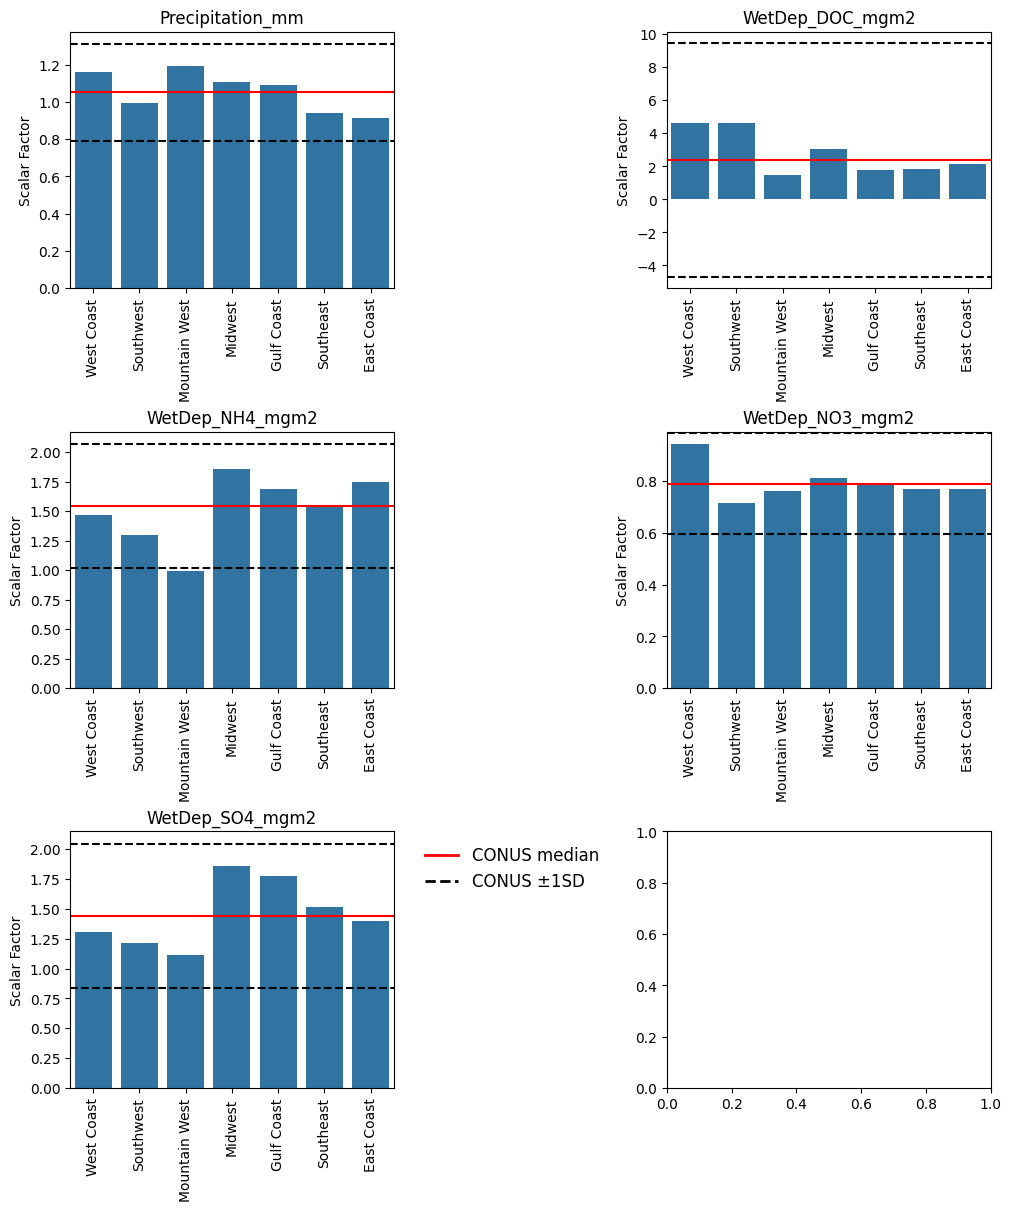

In [49]:
import matplotlib.pyplot as plt
import seaborn as sns
import math
from matplotlib.lines import Line2D

# Unique variables and layout setup
variables = factor_comparisons['Variable'].unique()
n_vars = len(variables)

ncols = 2
nrows = math.ceil(n_vars / ncols)

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(ncols*5, nrows*4), constrained_layout=True)
axes = axes.flatten()

# Plotting
for i, var in enumerate(variables):
    ax = axes[i]
    
    dat_plot = factor_comparisons[factor_comparisons.Variable == var]
    dat_plot_region = dat_plot[dat_plot.region != 'All']
    
    all_mean = dat_plot.loc[dat_plot.region == 'All', 'median'].item()
    all_sd_plus = all_mean + dat_plot.loc[dat_plot.region == 'All', 'std'].item()
    all_sd_minus = all_mean - dat_plot.loc[dat_plot.region == 'All', 'std'].item()
    
    sns.barplot(data=dat_plot_region, x='region', y='median', ax=ax)
    
    ax.set_title(var)
    ax.axhline(y=all_mean, color='red', linestyle='-', label='CONUS median')
    ax.axhline(y=all_sd_plus, color='black', linestyle='--', label='CONUS ±1SD')
    ax.axhline(y=all_sd_minus, color='black', linestyle='--')
    
    ax.tick_params(axis='x', rotation=90)
    ax.set_xlabel('')
    ax.set_ylabel('Scalar Factor')
    
    # Remove individual legends
    if ax.get_legend(): ax.get_legend().remove()

# Custom legend (large and placed near last subplot)
last_ax = axes[n_vars - 1]

legend_elements = [
    Line2D([0], [0], color='red', lw=2, linestyle='-', label='CONUS median'),
    Line2D([0], [0], color='black', lw=2, linestyle='--', label='CONUS ±1SD'),
]

# Position the legend slightly to the right and below the top of the last plot
last_ax.legend(
    handles=legend_elements,
    bbox_to_anchor=(1.05, 1),  # Shift legend right of the last plot
    loc='upper left',
    fontsize=12,  # Larger text
    borderaxespad=0.5,
    frameon=False
)
plt.savefig('/glade/u/home/demurray/External File Uploads/Figures/Regional_scalar_comparisons.jpg', format='jpg', dpi=300)

plt.show()


In [50]:
#Compare scalars by year and plot here (across time):
dat_time_factors = dat_all_monyr.groupby(['Variable', 'Year'])['Diff_factor'].agg(
    median='median',
    std='std',
).reset_index()

dat_all_factors['Year'] = 'All'

time_factor_comparisons = pd.concat([dat_time_factors, dat_all_factors])
time_factor_comparisons

,Variable,Year,median,std,count,region
0,Precipitation_mm,2002,0.952142,0.281446,NaN,NaN
1,Precipitation_mm,2003,0.987084,0.239827,NaN,NaN
2,Precipitation_mm,2004,0.977454,0.236468,NaN,NaN
3,Precipitation_mm,2005,1.025370,0.194266,NaN,NaN
4,Precipitation_mm,2006,1.027255,0.326624,NaN,NaN
...,...,...,...,...,...,...
0,Precipitation_mm,All,1.050804,0.260996,1764.0,All
1,WetDep_DOC_mgm2,All,2.388083,7.065624,595.0,All
2,WetDep_NH4_mgm2,All,1.544257,0.527046,1764.0,All
3,WetDep_NO3_mgm2,All,0.791229,0.196869,1764.0,All


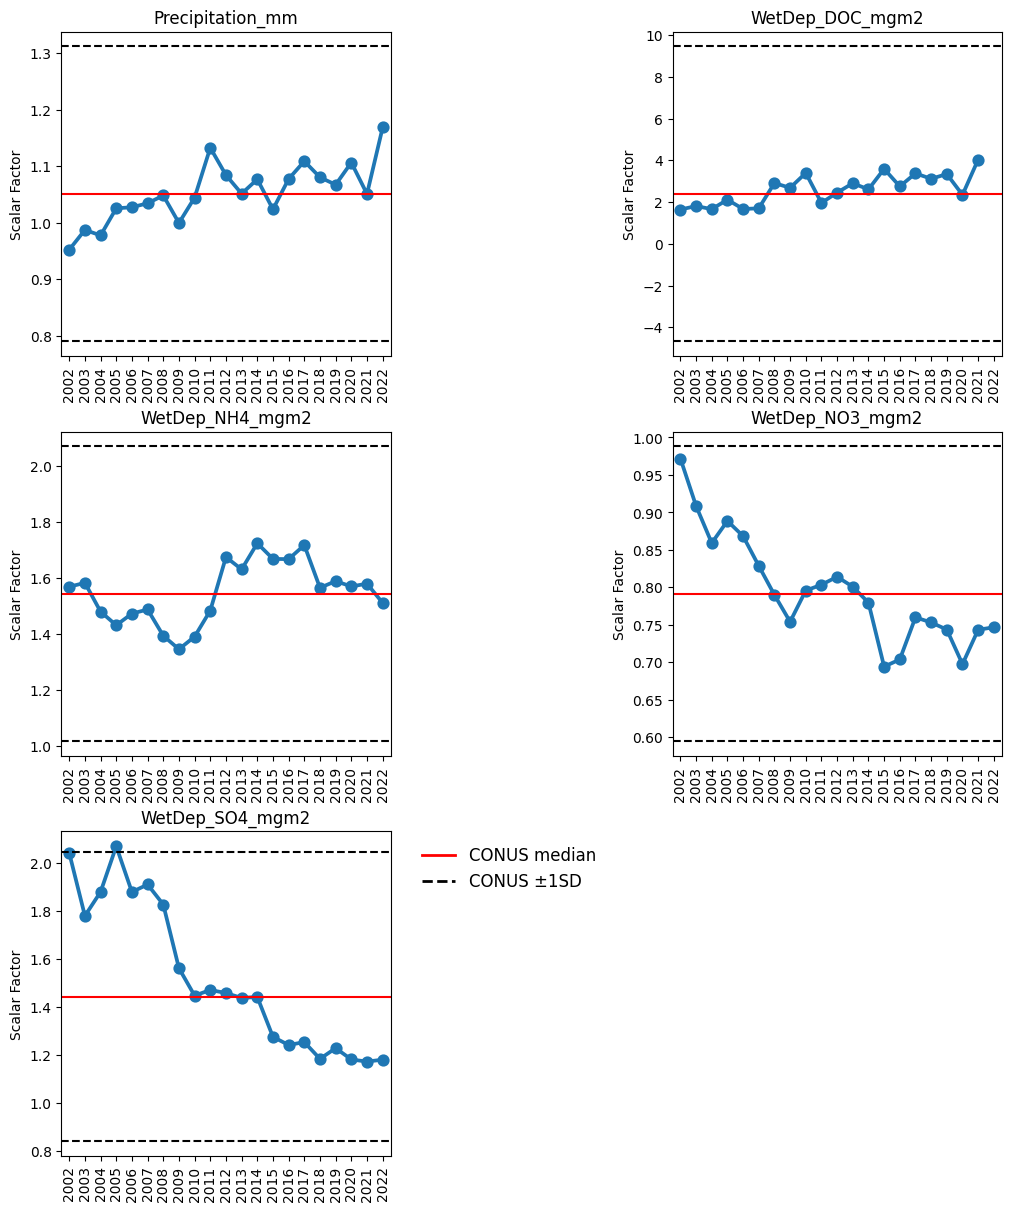

In [56]:
# Unique variables and layout setup
variables = time_factor_comparisons['Variable'].unique()
n_vars = len(variables)

ncols = 2
nrows = math.ceil(n_vars / ncols)

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(ncols*5, nrows*4), constrained_layout=True)
axes = axes.flatten()

# Plot each variable into its subplot
for i, var in enumerate(variables):
    ax = axes[i]

    dat_plot = time_factor_comparisons[time_factor_comparisons['Variable'] == var]
    dat_plot_time = dat_plot[dat_plot['Year'] != 'All']

    # Get CONUS stats
    all_mean = dat_plot.loc[dat_plot['Year'] == 'All', 'median'].item()
    all_sd_plus = all_mean + dat_plot.loc[dat_plot['Year'] == 'All', 'std'].item()
    all_sd_minus = all_mean - dat_plot.loc[dat_plot['Year'] == 'All', 'std'].item()

    # Plot
    sns.pointplot(data=dat_plot_time, x='Year', y='median', ax=ax)
    ax.axhline(y=all_mean, color='red', linestyle='-', label='CONUS temporal median')
    ax.axhline(y=all_sd_plus, color='black', linestyle='--', label='±1SD')
    ax.axhline(y=all_sd_minus, color='black', linestyle='--')

    ax.set_title(var)
    ax.set_xlabel('')
    ax.set_ylabel('Scalar Factor')
    ax.tick_params(axis='x', rotation=90)

    # Suppress legends from individual plots
    if ax.get_legend(): ax.get_legend().remove()

# Create one large, central legend on the last plot
last_ax = axes[n_vars - 1]
legend_elements = [
    Line2D([0], [0], color='red', lw=2, linestyle='-', label='CONUS median'),
    Line2D([0], [0], color='black', lw=2, linestyle='--', label='CONUS ±1SD'),
]
last_ax.legend(
    handles=legend_elements,
    bbox_to_anchor=(1.05, 1),  # adjust this for closer positioning
    loc='upper left',
    fontsize=12,
    frameon=False
)

# Remove unused axes (if any)
for j in range(n_vars, len(axes)):
    fig.delaxes(axes[j])
plt.savefig('/glade/u/home/demurray/External File Uploads/Figures/Temporal_scalar_comparisons.jpg', format='jpg', dpi=300)
plt.show()
